In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jatinmittal0001/rapido-rides/sample_rapido.xlsx
/kaggle/input/datasets/jatinmittal0001/rapido-rides/ct_rr.csv


In [2]:
df_ride = pd.read_excel('/kaggle/input/datasets/jatinmittal0001/rapido-rides/sample_rapido.xlsx')
df_ride.head()

,ts,number,pick_lat,pick_lng,drop_lat,drop_lng
0,2018-04-07 07:07:17,14626,12.313621,76.658195,12.287301,76.602280
1,2018-04-07 07:32:27,85490,12.943947,77.560745,12.954014,77.543770
2,2018-04-07 07:36:44,5408,12.899603,77.587300,12.934780,77.569950
3,2018-04-07 07:38:00,58940,12.918229,77.607544,12.968971,77.636375
4,2018-04-07 07:39:29,5408,12.899490,77.587270,12.934780,77.569950


In [3]:
df_rr = pd.read_csv('/kaggle/input/datasets/jatinmittal0001/rapido-rides/ct_rr.csv')
df_rr.head()

/tmp/ipykernel_16/271590651.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rr = pd.read_csv('/kaggle/input/datasets/jatinmittal0001/rapido-rides/ct_rr.csv')


,ts,number,pick_lat,pick_lng,drop_lat,drop_lng
0,2018-04-07 07:07:17,14626,12.313621,76.658195,12.287301,76.602280
1,2018-04-07 07:32:27,85490,12.943947,77.560745,12.954014,77.543770
2,2018-04-07 07:36:44,05408,12.899603,77.587300,12.934780,77.569950
3,2018-04-07 07:38:00,58940,12.918229,77.607544,12.968971,77.636375
4,2018-04-07 07:39:29,05408,12.899490,77.587270,12.934780,77.569950


In [4]:
print("shape of data frame of Ride",df_ride.shape)
df_ride.isnull().sum()

shape of data frame of Ride (22, 6)


ts          0
number      0
pick_lat    0
pick_lng    0
drop_lat    0
drop_lng    0
dtype: int64

In [5]:
print("shape of data frame of Ride rate", df_rr.shape)
df_rr.isnull().sum()

shape of data frame of Ride rate (8381556, 6)


ts          0
number      0
pick_lat    0
pick_lng    0
drop_lat    0
drop_lng    0
dtype: int64

In [6]:
df_ride.describe()

,ts,number,pick_lat,pick_lng,drop_lat,drop_lng
count,22,22.000000,22.000000,22.000000,22.000000,22.000000
mean,2018-04-07 07:54:44.545454336,51272.545455,12.895965,77.576069,12.912777,77.567295
min,2018-04-07 07:07:17,109.000000,12.313621,76.658195,12.287301,76.602280
25%,2018-04-07 07:43:19.750000128,21142.750000,12.889199,77.587306,12.920591,77.571105
50%,2018-04-07 07:55:14.500000,54603.000000,12.915035,77.607544,12.940012,77.595385
75%,2018-04-07 08:06:18,84632.500000,12.941330,77.652015,12.968971,77.636375
max,2018-04-07 08:21:12,99251.000000,12.994450,77.729546,12.980993,77.734670
std,NaN,34306.502240,0.136800,0.208744,0.142705,0.221989


In [7]:
df_rr.describe()

,pick_lat,pick_lng,drop_lat,drop_lng
count,8.381556e+06,8.381556e+06,8.381556e+06,8.381556e+06
mean,1.301024e+01,7.762875e+01,1.301084e+01,7.760709e+01
std,9.032779e-01,4.490899e-01,9.516462e-01,1.475269e+00
min,-4.877217e+01,-9.395859e+01,-5.794684e+01,-1.278179e+02
25%,1.291638e+01,7.759511e+01,1.291627e+01,7.759272e+01
50%,1.293741e+01,7.761597e+01,1.293895e+01,7.761737e+01
75%,1.297118e+01,7.764515e+01,1.297307e+01,7.764706e+01
max,6.769665e+01,9.281412e+01,6.152401e+01,1.748860e+02


### See peak hours in the data. Ride analysis

In [8]:
df_rr['ts'] = pd.to_datetime(df_rr['ts'])
df_rr.head()

,ts,number,pick_lat,pick_lng,drop_lat,drop_lng
0,2018-04-07 07:07:17,14626,12.313621,76.658195,12.287301,76.602280
1,2018-04-07 07:32:27,85490,12.943947,77.560745,12.954014,77.543770
2,2018-04-07 07:36:44,05408,12.899603,77.587300,12.934780,77.569950
3,2018-04-07 07:38:00,58940,12.918229,77.607544,12.968971,77.636375
4,2018-04-07 07:39:29,05408,12.899490,77.587270,12.934780,77.569950


In [9]:
df_rr['hour'] = df_rr['ts'].dt.hour
df_rr.tail()

,ts,number,pick_lat,pick_lng,drop_lat,drop_lng,hour
8381551,2019-04-07 23:55:24,50410,12.907856,77.55787,12.954270,77.530785,23
8381552,2019-04-07 23:58:15,12580,12.981010,77.69445,12.969070,77.704280,23
8381553,2019-04-07 22:11:20,72339,12.924252,77.65052,12.905820,77.630570,22
8381554,2019-04-07 22:12:30,72339,12.924252,77.65052,12.905820,77.630570,22
8381555,2019-04-07 15:00:55,28043,12.901222,77.59489,12.908599,77.649330,15


In [10]:
peak_hours = df_rr['hour'].value_counts().sort_index()

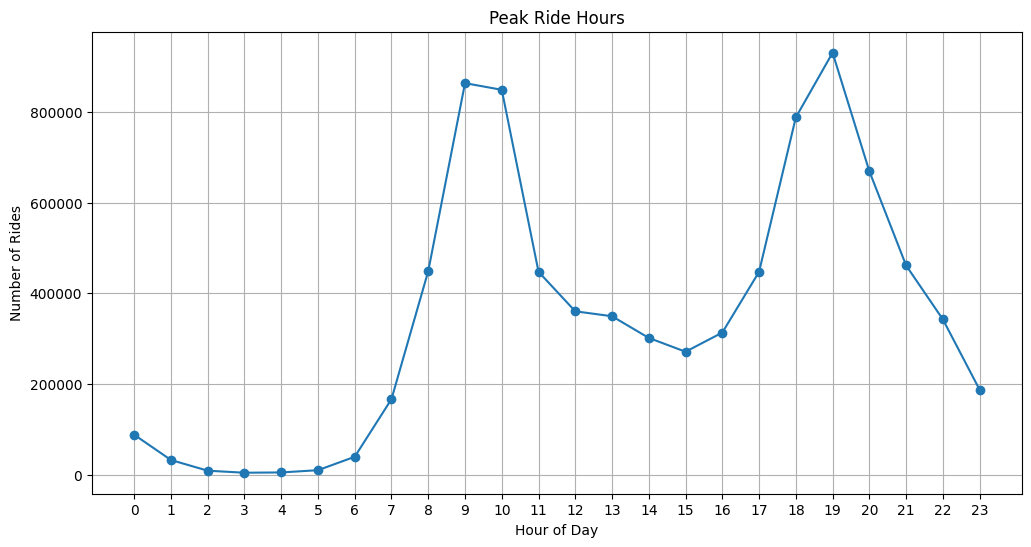

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(peak_hours.index, peak_hours.values, marker='o')

plt.title('Peak Ride Hours')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(range(0,24))
plt.grid(True)

plt.show()

### this shows that peak hours from 8 TO 11 HOUR. And 17 to 21 HOURS of the DAY.

### Getting mean pick up point to mean drop_point.

In [12]:
df_rr["hour"].mode()

0    19
Name: hour, dtype: int32

In [13]:
cols = ['pick_lat', 'pick_lng', 'drop_lat', 'drop_lng', 'hour']
print(df_rr[cols].mode())

    pick_lat   pick_lng   drop_lat  drop_lng  hour
0  12.929456  77.580284  12.932558  77.60358    19


In [14]:
def period(x):
    if 6 <= x < 12:
        return 'Morning'
    elif 12 <= x < 17:
        return 'Afternoon'
    elif 17 <= x < 22:
        return 'Evening'
    else:
        return 'Night'

df_rr['time_period'] = df_rr['hour'].apply(period)
df_rr.head()

,ts,number,pick_lat,pick_lng,drop_lat,drop_lng,hour,time_period
0,2018-04-07 07:07:17,14626,12.313621,76.658195,12.287301,76.602280,7,Morning
1,2018-04-07 07:32:27,85490,12.943947,77.560745,12.954014,77.543770,7,Morning
2,2018-04-07 07:36:44,05408,12.899603,77.587300,12.934780,77.569950,7,Morning
3,2018-04-07 07:38:00,58940,12.918229,77.607544,12.968971,77.636375,7,Morning
4,2018-04-07 07:39:29,05408,12.899490,77.587270,12.934780,77.569950,7,Morning


In [15]:
df_rr['time_period'].value_counts()

time_period
Evening      3296096
Morning      2814055
Afternoon    1594996
Night         676409
Name: count, dtype: int64